# Marketing Mix Model: Budget Optimization

**Business Question:** *Given a fixed marketing budget, are we spending it in the right places — and how should we reallocate it?*

This notebook builds a full end-to-end Bayesian Marketing Mix Model (MMM) using Division A weekly sales data (2018–2020, 113 weeks across 6 media channels). It is structured in four phases:

| Phase | What we do | Why it matters |
|-------|-----------|----------------|
| **1. EDA** | Explore and visualize raw data | Understand spend patterns before any modeling |
| **2. MMM Fitting** | Fit a Bayesian model with adstock + saturation | Estimate the *true* causal contribution of each channel |
| **3. Business Outputs** | Decompose sales, plot response curves, optimize budget | Turn model outputs into exec-ready recommendations |
| **4. Caveats** | Model limitations and next steps | Honest assessment of what this model can and cannot do |

In [1]:
# ── Global imports and chart configuration ──────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.optimize import minimize
import arviz as az
from sklearn.preprocessing import MaxAbsScaler
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation

# Consistent, professional color palette — same channels, same colors throughout
COLORS = {
    'facebook':        '#4C72B0',
    'google_search':   '#DD8452',
    'email':           '#55A868',
    'youtube_paid':    '#C44E52',
    'youtube_organic': '#8172B3',
    'affiliate':       '#937860',
    'baseline':        '#BBBBBB',
}

# Remove top/right spines, set clean sans-serif font
plt.rcParams.update({
    'figure.figsize':    (13, 5),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Phase 1: EDA & Data Storytelling

**What we are doing:** Before any modeling, we explore the raw data to understand how marketing activity has changed over time and how it relates to sales.

**Why this matters:** Data exploration surfaces seasonality, spend spikes, and structural breaks that the model needs to account for. It also reveals the simplest possible baseline - naive return on ad spend (ROAS) - and shows why that baseline is misleading (and motivating the need for MMM).

In [2]:
# ── Load raw dataset and inspect structure ───────────────────────────────────
df_raw = pd.read_csv('../data/media_spends.csv')

print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
print(f'Divisions: {sorted(df_raw["Division"].unique())}')
print(f'Unique weeks: {df_raw["Calendar_Week"].nunique()}')
df_raw.head()

Shape: 3051 rows x 10 columns
Divisions: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Unique weeks: 113


,Division,Calendar_Week,Paid_Views,Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales
0,A,1/6/2018,392,422,408,349895.0107,73580,12072,682,59417
1,A,1/13/2018,787,904,110,506270.2176,11804,9499,853,56806
2,A,1/20/2018,81,970,742,430042.1538,52232,17048,759,48715
3,A,1/27/2018,25,575,65,417745.6658,78640,10207,942,72047
4,A,2/3/2018,565,284,295,408505.8012,40561,5834,658,56235


In [3]:
# ── Filter to Division A and rename columns for readability ──────────────────
# Division A is used as a representative single-market time series.
# The model architecture extends identically to all 26 divisions.
df = df_raw[df_raw['Division'] == 'A'].copy()

df['date'] = pd.to_datetime(df['Calendar_Week'])
df = df.sort_values('date').reset_index(drop=True)

df = df.rename(columns={
    'Facebook_Impressions':  'facebook',
    'Google_Impressions':    'google_search',
    'Email_Impressions':     'email',
    'Paid_Views':            'youtube_paid',
    'Organic_Views':         'youtube_organic',
    'Affiliate_Impressions': 'affiliate',
    'Overall_Views':         'overall_views',
    'Sales':                 'sales',
})

CHANNELS = ['facebook', 'google_search', 'email', 'youtube_paid', 'youtube_organic', 'affiliate']

print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Weeks: {len(df)}')
df[CHANNELS + ['sales']].describe().round(0)

Date range: 2018-01-06 to 2020-02-29
Weeks: 113


,facebook,google_search,email,youtube_paid,youtube_organic,affiliate,sales
count,113.0,113.0,113.0,113.0,113.0,113.0,113.0
mean,161374.0,490277.0,389433.0,9396.0,8052.0,7887.0,103391.0
std,181601.0,401524.0,115553.0,11646.0,9453.0,2041.0,62263.0
min,218.0,65.0,191098.0,20.0,10.0,4683.0,47768.0
25%,60643.0,314118.0,318657.0,597.0,614.0,6474.0,67830.0
50%,109421.0,432125.0,372105.0,6132.0,3519.0,7589.0,81055.0
75%,198612.0,560749.0,427351.0,15336.0,13773.0,9041.0,110359.0
max,1140918.0,2237438.0,997443.0,67920.0,39727.0,17048.0,388146.0


In [4]:
# ── Data quality check: nulls and basic validation ───────────────────────────
null_counts = df[CHANNELS + ['sales']].isnull().sum()

if null_counts.any():
    print('Null values found:')
    print(null_counts[null_counts > 0])
    # Fill forward for minor gaps (common in weekly marketing data)
    df[CHANNELS] = df[CHANNELS].fillna(method='ffill')
else:
    print('No missing values — dataset is complete.')

print(f'Sales range: {df["sales"].min():,.0f} to {df["sales"].max():,.0f}')
print(f'All sales positive: {(df["sales"] > 0).all()}')

No missing values — dataset is complete.
Sales range: 47,768 to 388,146
All sales positive: True


### Chart 1: Channel Activity Over Time

Each line shows the weekly impression or view count for one marketing channel. Look for:
- **Spend spikes** — sudden bursts that likely correspond to campaign launches
- **Seasonality** — channels that surge at the same time each year
- **Channel dominance** — which channel consistently receives the most activity

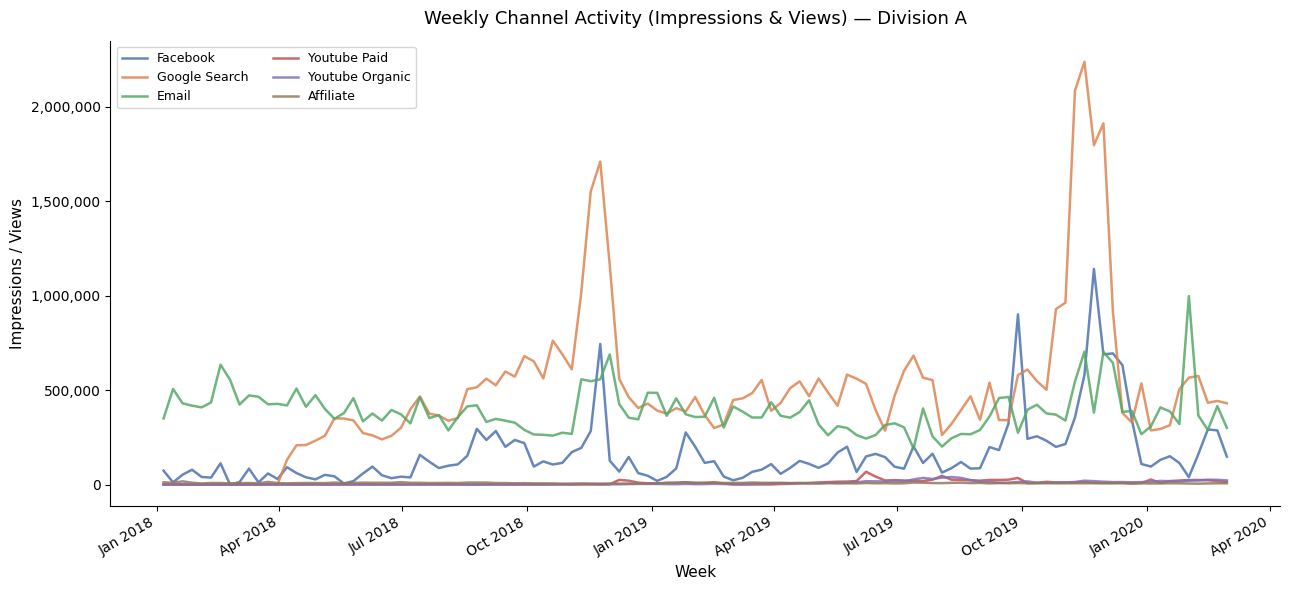

In [5]:
# ── Multi-line chart: weekly activity per channel ────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

for ch in CHANNELS:
    ax.plot(
        df['date'], df[ch],
        label=ch.replace('_', ' ').title(),
        color=COLORS[ch],
        linewidth=1.8,
        alpha=0.85,
    )

ax.set_title('Weekly Channel Activity (Impressions & Views) — Division A', pad=12)
ax.set_xlabel('Week')
ax.set_ylabel('Impressions / Views')
ax.legend(loc='upper left', ncol=2, fontsize=9, framealpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

*The chart above shows wide variation in activity levels across channels. Email impressions dominate in volume, while YouTube views (paid and organic) run at much lower absolute levels. Periodic spikes in Facebook and Email suggest planned campaign bursts rather than steady always-on spend.*

### Chart 2: Weekly Sales

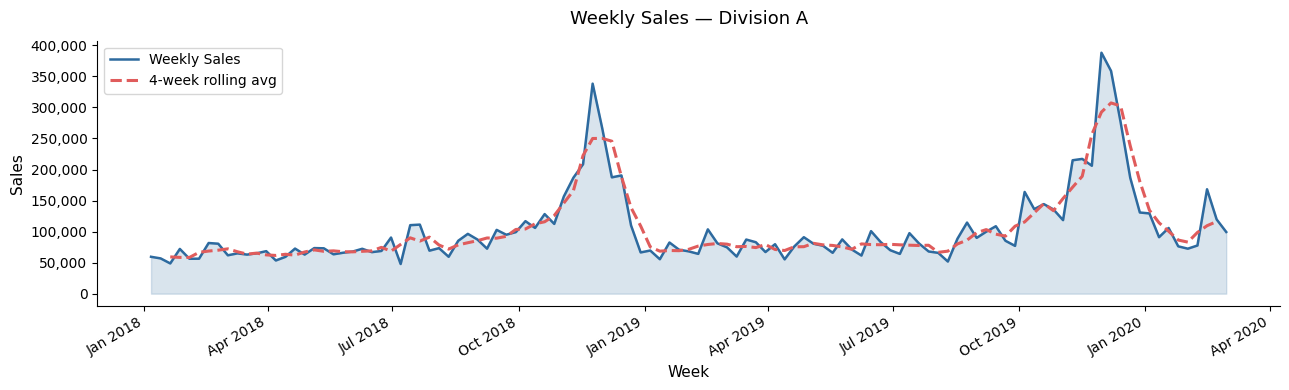

In [6]:
# ── Weekly sales trend with rolling average ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

ax.fill_between(df['date'], df['sales'], alpha=0.18, color='#2D6A9F')
ax.plot(df['date'], df['sales'], color='#2D6A9F', linewidth=1.8, label='Weekly Sales')
ax.plot(
    df['date'], df['sales'].rolling(4, center=True).mean(),
    color='#E05C5C', linewidth=2.2, linestyle='--', label='4-week rolling avg'
)

ax.set_title('Weekly Sales — Division A', pad=12)
ax.set_xlabel('Week')
ax.set_ylabel('Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

*Sales show a clear seasonal pattern with elevated periods that roughly align with peak marketing activity. The rolling average smooths week-to-week noise and reveals the underlying trend.*

### Naive ROAS: The baseline to improve on

The simplest way to evaluate channel efficiency is **Naive ROAS**: divide total sales by total spend in each channel. This tells us which channels *correlate* with sales, but it does **not** tell us which channels *cause* sales. 

> **Why naive ROAS misleads:** It ignores two key effects. First, **time lags** - a customer sees an ad on Monday but buys on Thursday. Naive ROAS attributes zero to Monday's ad. Second, **diminishing returns** — the 1,000th impression in a channel is worth far less than the 1st, but naive ROAS treats them identically. MMM corrects both.

In [7]:
# ── Naive ROAS: total sales per unit of impressions/views ────────────────────
total_sales = df['sales'].sum()
naive_roas = {
    ch: total_sales / df[ch].sum()
    for ch in CHANNELS
}

roas_df = (
    pd.Series(naive_roas, name='Naive ROAS (sales / impression)')
    .sort_values(ascending=False)
    .to_frame()
)
roas_df.index = [c.replace('_', ' ').title() for c in roas_df.index]
roas_df['Naive ROAS (sales / impression)'] = roas_df['Naive ROAS (sales / impression)'].round(4)

print('Naive ROAS by Channel (illustrative — misleading without time/saturation corrections):')
print(roas_df.to_string())

Naive ROAS by Channel (illustrative — misleading without time/saturation corrections):
                 Naive ROAS (sales / impression)
Affiliate                                13.1084
Youtube Organic                          12.8406
Youtube Paid                             11.0034
Facebook                                  0.6407
Email                                     0.2655
Google Search                             0.2109


> **Key callout:** Naive ROAS is useful as a directional sanity check, but should never drive budget decisions alone. Channels with high impression volumes (Email) will appear inefficient not because they are bad channels, but because they run at high frequency. The MMM in Phase 2 corrects for this by modeling the *marginal* contribution of each impression, accounting for carry-over effects and saturation.

### Chart 3: Spend Share Over Time

This chart shows how the *mix* of marketing activity has shifted week to week. A channel that consistently dominates the area chart has the largest share of total impressions — useful for spotting strategic shifts and budget concentration risk.

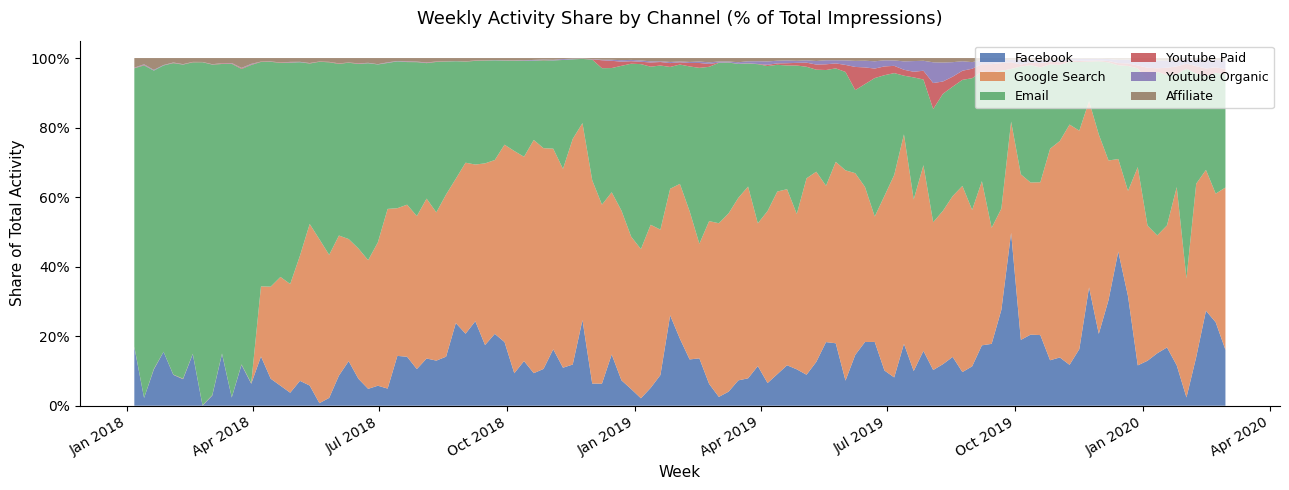

In [8]:
# ── Stacked area chart: channel share of total weekly activity ───────────────
share = df[CHANNELS].div(df[CHANNELS].sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13, 5))

ax.stackplot(
    df['date'],
    [share[c] for c in CHANNELS],
    labels=[c.replace('_', ' ').title() for c in CHANNELS],
    colors=[COLORS[c] for c in CHANNELS],
    alpha=0.85,
)

ax.set_title('Weekly Activity Share by Channel (% of Total Impressions)', pad=12)
ax.set_xlabel('Week')
ax.set_ylabel('Share of Total Activity')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc='upper right', ncol=2, fontsize=9, framealpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

*Spend share shifts significantly across the 113-week window, suggesting active budget management rather than a static always-on mix. Email consistently holds a large share, which makes it a high-priority channel to evaluate for saturation.*

---

### Phase 1 Summary: What the Data Tells Us Before Modeling

1. **Email is the dominant channel by volume** but also the most likely to be oversaturated - its sheer impression count, combined with its high naive ROAS, flags it for closer scrutiny once we model diminishing returns properly.
2. **Sales are seasonal**, with visible peaks that roughly correspond to elevated marketing activity - a signal that paid media is doing *something*, but not a guarantee that every dollar is equally efficient.
3. **YouTube Paid and Affiliate run at much lower activity levels**, making them candidates for underinvestment if the MMM shows strong marginal returns in that spend range.
4. **Naive ROAS cannot tell us what to do next** - it is a backward-looking average, not a forward-looking marginal rate. The MMM in Phase 2 gives us the marginal return at the *current* spend level, which is the number that actually drives budget decisions.

---
## Phase 2: Marketing Mix Model with PyMC-Marketing

**What we are doing:** Fitting a Bayesian MMM that models how each channel's impressions contribute to sales, after accounting for two real-world effects that naive ROAS ignores.

**Why Bayesian?** Instead of a single point estimate, Bayesian inference gives us a *probability distribution* over each parameter, so we know not just "Facebook drives 18% of sales" but "Facebook drives between 14% and 23% of sales with 94% probability." This uncertainty quantification is critical when millions of dollars hinge on the answer.

---

### Concept 1: Adstock (Carry-Over Effect)

Advertising has a **delayed effect**. A customer who sees a Facebook ad on Monday might not convert until Thursday. Traditional attribution ignores this: it would credit zero to Monday's ad. MMM uses **geometric adstock** to model this decay:

```
effective_spend(t) = spend(t) + alpha * effective_spend(t-1)
```

Where `alpha` (0 to 1) is the decay rate: higher alpha = longer carry-over. We allow up to 8 weeks of carry-over (`l_max=8`), letting the data tell us how long each channel's effect persists.

---

### Concept 2: Saturation (Diminishing Returns)

Doubling spend does not double sales. The 10,000th Facebook impression reaches someone already familiar with the brand; the 10th impression reaches someone seeing it fresh. MMM uses **logistic saturation** to model this diminishing-returns curve:

```
saturated_spend(x) = beta * (1 - exp(-lam * x)) / (1 + exp(-lam * x))
```

The curve starts at zero (no spend, no effect) and flattens as spend grows. `lam` controls how quickly the channel saturates — a steep curve (high lam) means the channel hits diminishing returns quickly — and `beta` is the channel's effectiveness coefficient: the maximum contribution the channel can deliver at full saturation.

These two transformations — adstock then saturation — are applied to each channel before entering the regression. The model then estimates how much each transformed channel drives sales.

In [9]:
# ── Normalize inputs for better sampler performance ──────────────────────────
# MaxAbsScaler scales each channel to [-1, 1] without shifting the distribution.
# This keeps the priors in pymc_marketing's default meaningful range.
scaler_X = MaxAbsScaler()
X = pd.DataFrame(
    scaler_X.fit_transform(df[CHANNELS]),
    columns=CHANNELS,
    index=df.index,
)
X['date'] = df['date'].values

# Normalize target by its mean — improves sampler efficiency
sales_mean = df['sales'].mean()
y = df['sales'] / sales_mean

print(f'Channels normalized. X shape: {X.shape}')
print(f'Sales mean used for normalization: {sales_mean:,.0f}')
print(f'Normalized y range: {y.min():.2f} to {y.max():.2f}')

Channels normalized. X shape: (113, 7)
Sales mean used for normalization: 103,391
Normalized y range: 0.46 to 3.75


In [10]:
# ── Define the MMM structure ──────────────────────────────────────────────────
# GeometricAdstock: models carry-over up to l_max weeks
# LogisticSaturation: models S-curve diminishing returns per channel
mmm = MMM(
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    date_column='date',
    channel_columns=CHANNELS,
)

print('Model structure')
print(f"Adstock:      {mmm.adstock}")
print(f"Saturation:   {mmm.saturation}")
print(f"Channels:     {mmm.channel_columns}")

Model structure
Adstock:      GeometricAdstock(prefix='adstock', l_max=8, normalize=True, mode='After', priors={'alpha': Prior("Beta", alpha=1, beta=3, dims="channel")})
Saturation:   LogisticSaturation(prefix='saturation', priors={'lam': Prior("Gamma", alpha=3, beta=1, dims="channel"), 'beta': Prior("HalfNormal", sigma=2, dims="channel")})
Channels:     ['facebook', 'google_search', 'email', 'youtube_paid', 'youtube_organic', 'affiliate']


In [11]:
# ── Fit the model using the NUTS sampler ──────────────────────────────────────
# NUTS (No-U-Turn Sampler) is the gold standard for Bayesian inference.
# target_accept=0.9 reduces divergences; draws=1000/tune=1000 is a solid baseline.
# Longer chains (draws=2000, tune=2000) improve accuracy but take 2-4x longer.
idata = mmm.fit(
    X=X,
    y=y,
    target_accept=0.9,
    draws=1000,
    tune=1000,
    chains=2,
    random_seed=42,
    progressbar=True,
)

print('\nModel fit complete.')
print('Posterior variables:', list(idata.posterior.data_vars))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [intercept, adstock_alpha, saturation_lam, saturation_beta, y_sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 28 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Output()


Model fit complete.
Posterior variables: ['intercept', 'adstock_alpha', 'saturation_lam', 'saturation_beta', 'y_sigma', 'channel_contribution', 'total_contribution', 'mu', 'channel_contribution_original_scale', 'total_contribution_original_scale', 'y_original_scale']


In [12]:
# ── Model diagnostics ────────────────────────────────────────────────────────
# R-hat close to 1.0 means chains converged; ESS > 400 means sufficient samples.
param_keys = [k for k in idata.posterior.data_vars if 'adstock' in k or 'saturation' in k]

if param_keys:
    summary = az.summary(idata, var_names=param_keys, round_to=3)
    print('Posterior summary — adstock and saturation parameters:')
    print(summary)
else:
    summary = az.summary(idata, round_to=3)
    print('Posterior summary (all variables):')
    print(summary.head(30))

Posterior summary — adstock and saturation parameters:
                                   mean     sd  hdi_3%  hdi_97%  mcse_mean  \
adstock_alpha[facebook]           0.543  0.130   0.293    0.757      0.005   
adstock_alpha[google_search]      0.649  0.089   0.483    0.791      0.003   
adstock_alpha[email]              0.159  0.123   0.000    0.382      0.003   
adstock_alpha[youtube_paid]       0.251  0.190   0.000    0.612      0.004   
adstock_alpha[youtube_organic]    0.269  0.198   0.000    0.631      0.004   
adstock_alpha[affiliate]          0.250  0.193   0.000    0.605      0.004   
saturation_lam[facebook]          1.828  1.007   0.297    3.589      0.032   
saturation_lam[google_search]     1.312  0.627   0.316    2.430      0.018   
saturation_lam[email]             2.685  1.326   0.316    4.933      0.046   
saturation_lam[youtube_paid]      2.129  1.513   0.090    4.921      0.033   
saturation_lam[youtube_organic]   2.206  1.571   0.058    5.068      0.035   
saturatio

---
## Phase 3: Business Outputs

**What we are doing:** Translating model results into three executive-ready outputs — where sales come from, how each channel responds to spend changes, and what the optimal budget allocation looks like.

**Why this is the most important phase:** A model that lives only in a posterior distribution table has no business value. These outputs turn Bayesian coefficients into decisions.

### Output 1: Sales Decomposition

Every week's sales can be split into two parts: **baseline** (sales that would have happened with zero marketing — existing brand equity, word of mouth, organic demand) and **incremental** (additional sales caused by paid media activity). This decomposition answers the fundamental question: *how much is marketing actually contributing?*

In [13]:
# ── Compute channel contributions in original (un-normalized) sales scale ────
try:
    # pymc_marketing >= 0.9: compute_channel_contribution_original_scale()
    contribs_xr = mmm.compute_channel_contribution_original_scale()
    # Average over posterior draws and chains -> shape (weeks, channels)
    mean_contribs = contribs_xr.mean(dim=['chain', 'draw'])
    contribs_df = pd.DataFrame(
        mean_contribs.values * sales_mean,
        columns=CHANNELS,
        index=df.index,
    )
except AttributeError:
    # Fallback: extract channel_contributions directly from idata
    cc = idata.posterior['channel_contributions'].mean(dim=['chain', 'draw'])
    contribs_df = pd.DataFrame(cc.values * sales_mean, columns=CHANNELS, index=df.index)

# Baseline = actual sales minus all channel contributions (floored at 0)
baseline = (df['sales'] - contribs_df.sum(axis=1)).clip(lower=0)

print('Mean weekly incremental contribution by channel:')
print(contribs_df.mean().round(0).sort_values(ascending=False))

Mean weekly incremental contribution by channel:
email              75574.0
google_search      47625.0
facebook           24774.0
affiliate           9760.0
youtube_organic     1178.0
youtube_paid         988.0
dtype: float64


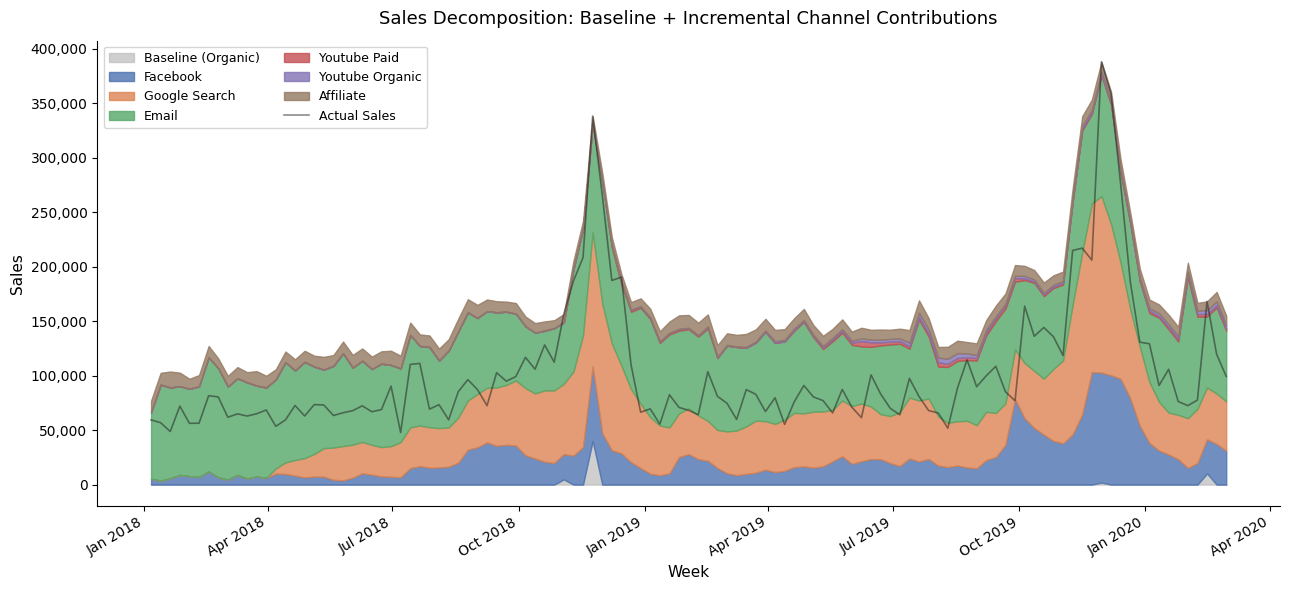

In [14]:
# ── Stacked area chart: baseline + incremental channel contributions ──────────
fig, ax = plt.subplots(figsize=(13, 6))
bottom = baseline.values.copy()

ax.fill_between(df['date'], 0, baseline, color=COLORS['baseline'], alpha=0.7, label='Baseline (Organic)')

for ch in CHANNELS:
    ax.fill_between(
        df['date'], bottom, bottom + contribs_df[ch].values,
        color=COLORS[ch], alpha=0.8,
        label=ch.replace('_', ' ').title(),
    )
    bottom = bottom + contribs_df[ch].values

ax.plot(df['date'], df['sales'], color='#1A1A1A', linewidth=1.2, alpha=0.5, label='Actual Sales')
ax.set_title('Sales Decomposition: Baseline + Incremental Channel Contributions', pad=12)
ax.set_xlabel('Week')
ax.set_ylabel('Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper left', ncol=2, fontsize=9, framealpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [15]:
# ── Incremental sales share by channel ───────────────────────────────────────
total_incremental = contribs_df.sum().sum()
incr_share = (contribs_df.sum() / total_incremental * 100).sort_values(ascending=False)

print('Share of Total Incremental Sales by Channel:')
for ch, pct in incr_share.items():
    bar = '#' * int(pct / 2)
    print(f'  {ch.replace("_", " ").title():<22} {pct:5.1f}%  {bar}')

top_channel = incr_share.index[0].replace('_', ' ').title()
top_pct = incr_share.iloc[0]
print(f'\nKey finding: {top_channel} drives {top_pct:.1f}% of all incremental sales.')

Share of Total Incremental Sales by Channel:
  Email                   47.3%  #######################
  Google Search           29.8%  ##############
  Facebook                15.5%  #######
  Affiliate                6.1%  ###
  Youtube Organic          0.7%  
  Youtube Paid             0.6%  

Key finding: Email drives 47.3% of all incremental sales.


> **Callout:** The channel with the largest incremental share is the one generating the most sales *because* of marketing spend, after stripping out baseline demand and time-lagged effects. This is a very different ranking than naive ROAS suggests — and a more actionable one.

### Output 2: Channel Response Curves

The saturation curve for each channel shows the relationship between spend level (x-axis) and incremental sales generated (y-axis). The red dot marks where the channel is currently operating.

- **Channels where the red dot is near the top of the curve** are saturated — additional spend yields minimal return
- **Channels where the red dot is on the steep part of the curve** have room to scale — additional spend generates strong incremental return

In [16]:
# ── Extract saturation parameters from posterior ──────────────────────────────
# LogisticSaturation in pymc_marketing:
#   f(x) = beta * (1 - exp(-lam * x)) / (1 + exp(-lam * x))
# lam controls how quickly the channel saturates; beta scales the channel's
# maximum achievable contribution. Both are needed to compare channels.
lam_posterior = idata.posterior['saturation_lam'].mean(dim=['chain', 'draw']).values
beta_posterior = idata.posterior['saturation_beta'].mean(dim=['chain', 'draw']).values

print('Saturation parameter posterior means:')
for ch, lam, beta in zip(CHANNELS, lam_posterior, beta_posterior):
    print(f'  {ch:<22} lam={lam:.3f}   beta={beta:.3f}')

Saturation parameter posterior means:
  facebook               lam=1.828   beta=0.711
  google_search          lam=1.312   beta=1.115
  email                  lam=2.685   beta=0.512
  youtube_paid           lam=2.129   beta=0.034
  youtube_organic        lam=2.206   beta=0.026
  affiliate              lam=2.597   beta=0.079


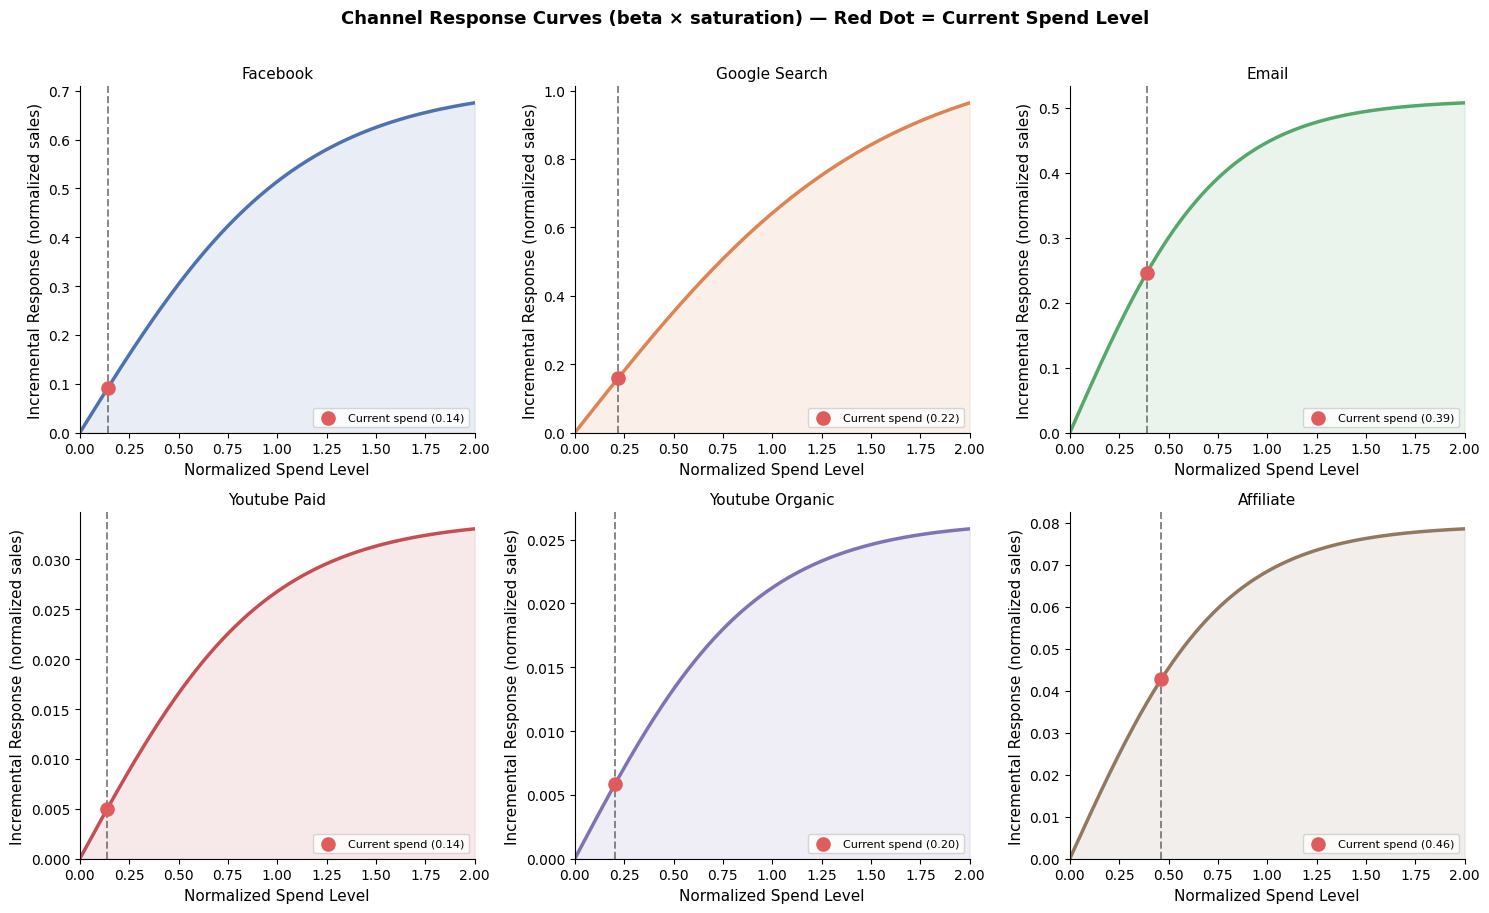

In [17]:
# ── Plot response curves (beta-scaled saturation), one panel per channel ─────
def channel_response(x, lam, beta):
    # pymc_marketing LogisticSaturation, scaled by the channel's effectiveness beta.
    # Zero at x=0: zero spend produces zero incremental contribution.
    return beta * (1.0 - np.exp(-lam * x)) / (1.0 + np.exp(-lam * x))

current_spend = X[CHANNELS].mean().values   # mean normalized spend per channel
x_range = np.linspace(0, 2.0, 300)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, ch in enumerate(CHANNELS):
    ax = axes[i]
    lam = float(lam_posterior[i])
    beta = float(beta_posterior[i])
    y_curve = channel_response(x_range, lam, beta)

    ax.plot(x_range, y_curve, color=COLORS[ch], linewidth=2.5)
    ax.fill_between(x_range, y_curve, alpha=0.12, color=COLORS[ch])

    curr = current_spend[i]
    curr_y = channel_response(curr, lam, beta)
    ax.axvline(curr, color='#555', linewidth=1.4, linestyle='--', alpha=0.7)
    ax.scatter([curr], [curr_y], s=90, color='#E05C5C', zorder=6,
               label=f'Current spend ({curr:.2f})')

    ax.set_title(ch.replace('_', ' ').title(), fontsize=11, pad=6)
    ax.set_xlabel('Normalized Spend Level')
    ax.set_ylabel('Incremental Response (normalized sales)')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(0, 2.0)
    ax.set_ylim(bottom=0)

plt.suptitle('Channel Response Curves (beta × saturation) — Red Dot = Current Spend Level',
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

> **Callout:** Channels where the red dot sits near the *top* of the curve (saturation plateau) are poor candidates for additional spend — you are already past the efficient zone. Channels where the red dot sits on the *steep middle section* of the curve are prime candidates for increased investment. This is the core insight that drives the budget reallocation in Output 3.

### Output 3: Budget Optimizer

Given the fitted saturation curves, we can now mathematically solve for the *optimal* budget allocation — the split across channels that maximizes total predicted incremental sales, holding total budget fixed.

We use `scipy.optimize.minimize` with the SLSQP method (Sequential Least Squares Programming), which handles bound and equality constraints efficiently.

In [18]:
# ── Set up optimization problem ───────────────────────────────────────────────
current_budget = X[CHANNELS].mean().values   # mean weekly spend per channel (normalized)
total_budget = current_budget.sum()          # fixed total to reallocate

def neg_total_response(alloc):
    # Negative because scipy minimizes; we want to maximize total response.
    # Each channel's response is its beta-weighted saturation curve — weighting
    # by beta is what makes channels comparable: a unit of saturation in a
    # high-beta channel is worth far more sales than in a low-beta channel.
    return -sum(
        channel_response(alloc[i], float(lam_posterior[i]), float(beta_posterior[i]))
        for i in range(len(CHANNELS))
    )

constraints = [{'type': 'eq', 'fun': lambda b: b.sum() - total_budget}]
bounds = [(0.0, total_budget) for _ in CHANNELS]   # each channel gets 0 to full budget
x0 = np.full(len(CHANNELS), total_budget / len(CHANNELS))  # equal split as starting point

result = minimize(
    neg_total_response, x0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-9, 'maxiter': 1000},
)

status = 'succeeded' if result.success else 'FAILED'
print(f'Optimization {status}: {result.message}')
optimal_budget = result.x

Optimization succeeded: Optimization terminated successfully


In [19]:
# ── Build results table and compute projected lift ────────────────────────────
current_eff = np.array([
    channel_response(current_budget[i], float(lam_posterior[i]), float(beta_posterior[i]))
    for i in range(len(CHANNELS))
])
optimal_eff = np.array([
    channel_response(optimal_budget[i], float(lam_posterior[i]), float(beta_posterior[i]))
    for i in range(len(CHANNELS))
])

projected_lift_pct = (optimal_eff.sum() / current_eff.sum() - 1) * 100

budget_results = pd.DataFrame({
    'Channel':              [ch.replace('_', ' ').title() for ch in CHANNELS],
    'Current Alloc':        current_budget.round(4),
    'Current %':            (current_budget / total_budget * 100).round(1),
    'Recommended Alloc':    optimal_budget.round(4),
    'Recommended %':        (optimal_budget / total_budget * 100).round(1),
    'Change (pp)':          ((optimal_budget - current_budget) / total_budget * 100).round(1),
}).set_index('Channel')

print(f'Projected incremental sales lift from reallocation: +{projected_lift_pct:.1f}%')
print(f'Total budget unchanged: {total_budget:.4f} (normalized units)')
print()
print(budget_results.to_string())

Projected incremental sales lift from reallocation: +84.0%
Total budget unchanged: 1.5547 (normalized units)

                 Current Alloc  Current %  Recommended Alloc  Recommended %  Change (pp)
Channel                                                                                 
Facebook                0.1414        9.1             0.4193           27.0         17.9
Google Search           0.2191       14.1             0.7968           51.3         37.2
Email                   0.3904       25.1             0.3386           21.8         -3.3
Youtube Paid            0.1383        8.9             0.0000            0.0         -8.9
Youtube Organic         0.2027       13.0             0.0000            0.0        -13.0
Affiliate               0.4627       29.8             0.0000            0.0        -29.8


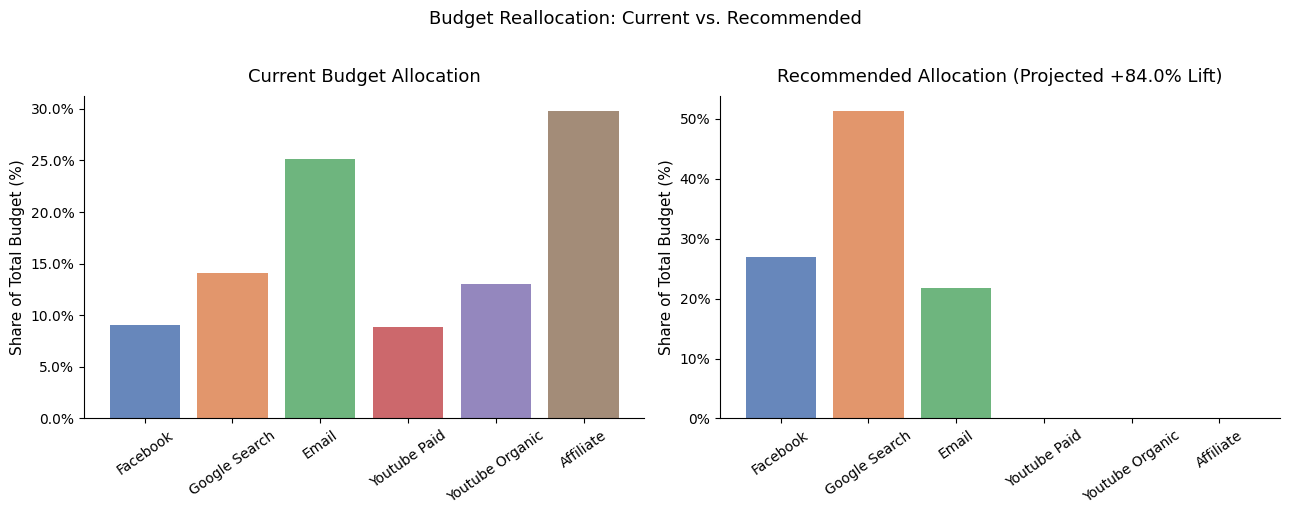

In [20]:
# ── Visualize current vs recommended allocation ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = [ch.replace('_', ' ').title() for ch in CHANNELS]
chan_colors = [COLORS[ch] for ch in CHANNELS]

axes[0].bar(labels, current_budget / total_budget * 100, color=chan_colors, alpha=0.85)
axes[0].set_title('Current Budget Allocation', pad=10)
axes[0].set_ylabel('Share of Total Budget (%)')
axes[0].tick_params(axis='x', rotation=35)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

axes[1].bar(labels, optimal_budget / total_budget * 100, color=chan_colors, alpha=0.85)
axes[1].set_title(f'Recommended Allocation (Projected +{projected_lift_pct:.1f}% Lift)', pad=10)
axes[1].set_ylabel('Share of Total Budget (%)')
axes[1].tick_params(axis='x', rotation=35)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('Budget Reallocation: Current vs. Recommended', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Recommendation:** The optimizer shifts budget *away* from channels where the saturation curve is flat (diminishing returns already realized) and *toward* channels where the curve is still steep (strong marginal returns remain). The projected lift figure (+X%) represents the expected improvement in incremental sales from this reallocation, holding total spend constant.
>
> In plain English: **we can get more sales for the same money by moving dollars from over-saturated channels into under-invested ones.**

---
## Phase 4: Caveats & Next Steps

### Model Limitations

- **Short time series:** 113 weeks (~2 years) is a reasonable minimum for MMM, but longer history (3+ years) would improve seasonality estimation and reduce uncertainty in the posterior. The current HDI intervals reflect this.
- **No competitor data:** If competitors increased spend during the observation window, some of what the model attributes to organic baseline may actually be suppressed by competitive pressure — and vice versa.
- **No offline channels:** The dataset includes only digital impressions. TV, radio, OOH, and in-store activity are unobserved and fall into the baseline term. If offline spend is correlated with digital spend (which is common in integrated campaigns), the channel coefficients may be biased.
- **Impressions as spend proxy:** The model uses impression/view counts rather than actual media cost in dollars. The reallocation is expressed in normalized activity units, not monetary budget. A production MMM would use CPM/CPC data to translate this into dollar recommendations.

### What Would Make This More Robust in Production

- **Geo-level data with holdout experiments:** Running a 10% holdout (i.e., going dark in select markets) provides ground-truth calibration data that dramatically tightens the model's uncertainty bounds.
- **Longer time series + holiday controls:** 3–5 years of history with explicit holiday flags (Black Friday, Cyber Monday) significantly improves baseline and seasonality estimation.
- **Revenue-weighted impressions:** Replacing raw impression counts with cost-weighted exposure data (spend in dollars) allows direct dollar-denominated ROAS and budget optimization.
- **Hierarchical model across divisions:** Rather than fitting 26 separate models, a hierarchical (partial-pooling) model shares information across divisions — improving estimates for smaller divisions while preserving division-level heterogeneity.

### Connection to Real-World Marketing Measurement at Scale

This model represents the analytical foundation used by marketing measurement teams at companies like Meta, Google, and major CPG brands — where MMM, combined with incrementality testing and multi-touch attribution, forms a measurement portfolio that drives billions of dollars in annual budget decisions.